In [1]:
import pandas as pd
df=pd.read_csv("azzsdata2022.txt",sep="\t")

df.head()

,city,time,so2,pm10,no2,nox,co,no,pm25,p,t,rh
0,Belgrade,30/12/2021,7.35,36.92,45.49,127.47,0.88,53.37,32.32,1010.22,6.20,90.07
1,Belgrade,31/12/2021,20.87,89.90,70.12,414.02,2.04,224.31,77.31,1012.67,8.79,82.54
2,Belgrade,01/01/2022,10.93,64.43,38.83,133.12,1.30,61.54,59.86,1012.87,10.04,82.36
3,Belgrade,02/01/2022,15.21,42.57,55.74,198.03,1.12,92.96,37.21,1012.73,11.14,75.14
4,Belgrade,03/01/2022,13.99,68.64,63.15,292.04,1.54,149.28,60.49,1006.57,9.09,77.98


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    81 non-null     object 
 1   time    81 non-null     object 
 2   so2     81 non-null     float64
 3   pm10    81 non-null     float64
 4   no2     81 non-null     float64
 5   nox     81 non-null     float64
 6   co      81 non-null     float64
 7   no      81 non-null     float64
 8   pm25    81 non-null     float64
 9   p       81 non-null     float64
 10  t       81 non-null     float64
 11  rh      81 non-null     float64
dtypes: float64(10), object(2)
memory usage: 7.7+ KB


In [3]:
df.drop(columns=['city'], inplace=True)
df.head()

,time,so2,pm10,no2,nox,co,no,pm25,p,t,rh
0,30/12/2021,7.35,36.92,45.49,127.47,0.88,53.37,32.32,1010.22,6.20,90.07
1,31/12/2021,20.87,89.90,70.12,414.02,2.04,224.31,77.31,1012.67,8.79,82.54
2,01/01/2022,10.93,64.43,38.83,133.12,1.30,61.54,59.86,1012.87,10.04,82.36
3,02/01/2022,15.21,42.57,55.74,198.03,1.12,92.96,37.21,1012.73,11.14,75.14
4,03/01/2022,13.99,68.64,63.15,292.04,1.54,149.28,60.49,1006.57,9.09,77.98


In [4]:
df.describe()

,so2,pm10,no2,nox,co,no,pm25,p,t,rh
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,11.414568,44.628272,51.168642,142.340988,1.082346,60.542716,34.574568,1011.722099,5.257531,65.856049
std,5.456263,21.899804,15.892835,88.143907,0.319563,49.750838,17.209154,7.643771,3.835367,13.967888
min,3.670000,15.020000,20.800000,29.010000,0.660000,5.360000,9.860000,994.210000,-4.070000,33.910000
25%,7.130000,27.840000,38.830000,81.540000,0.850000,26.320000,19.990000,1006.560000,3.000000,57.510000
50%,10.930000,39.120000,50.920000,121.790000,0.960000,43.180000,31.760000,1012.320000,5.240000,67.840000
75%,15.120000,57.950000,63.210000,198.030000,1.270000,86.080000,45.580000,1016.860000,8.180000,76.340000
max,28.260000,119.560000,91.140000,419.510000,2.040000,224.310000,77.310000,1029.090000,13.610000,92.600000


In [5]:
df['time'] = pd.to_datetime(df['time'], dayfirst=True)
df.head()

,time,so2,pm10,no2,nox,co,no,pm25,p,t,rh
0,2021-12-30,7.35,36.92,45.49,127.47,0.88,53.37,32.32,1010.22,6.20,90.07
1,2021-12-31,20.87,89.90,70.12,414.02,2.04,224.31,77.31,1012.67,8.79,82.54
2,2022-01-01,10.93,64.43,38.83,133.12,1.30,61.54,59.86,1012.87,10.04,82.36
3,2022-01-02,15.21,42.57,55.74,198.03,1.12,92.96,37.21,1012.73,11.14,75.14
4,2022-01-03,13.99,68.64,63.15,292.04,1.54,149.28,60.49,1006.57,9.09,77.98


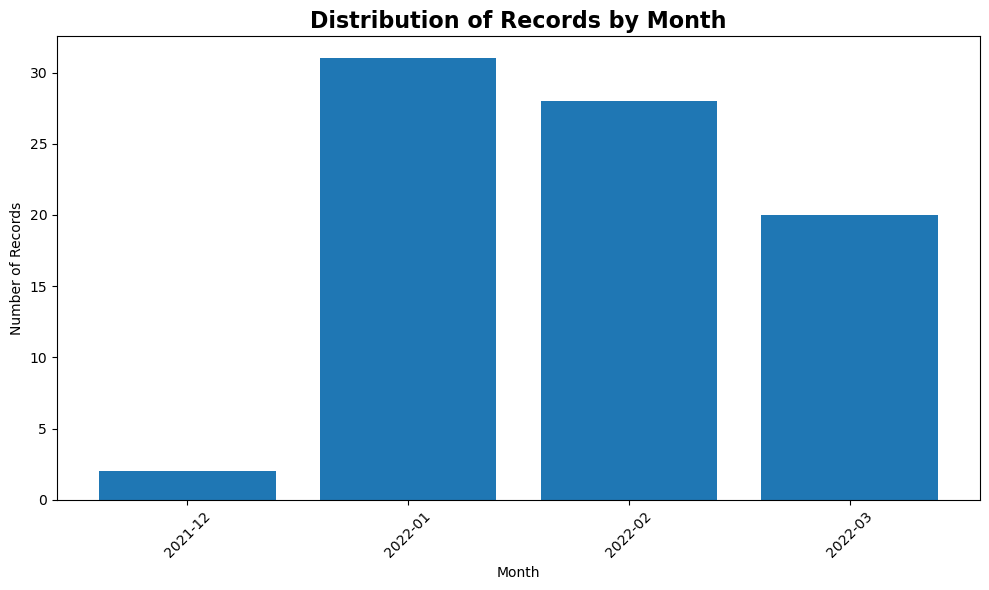

Month distribution:
time
2021-12     2
2022-01    31
2022-02    28
2022-03    20
Freq: M, Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt

month_counts = df['time'].dt.to_period('M').value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.bar(month_counts.index.astype(str), month_counts.values)
plt.title('Distribution of Records by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Month distribution:")
print(month_counts)


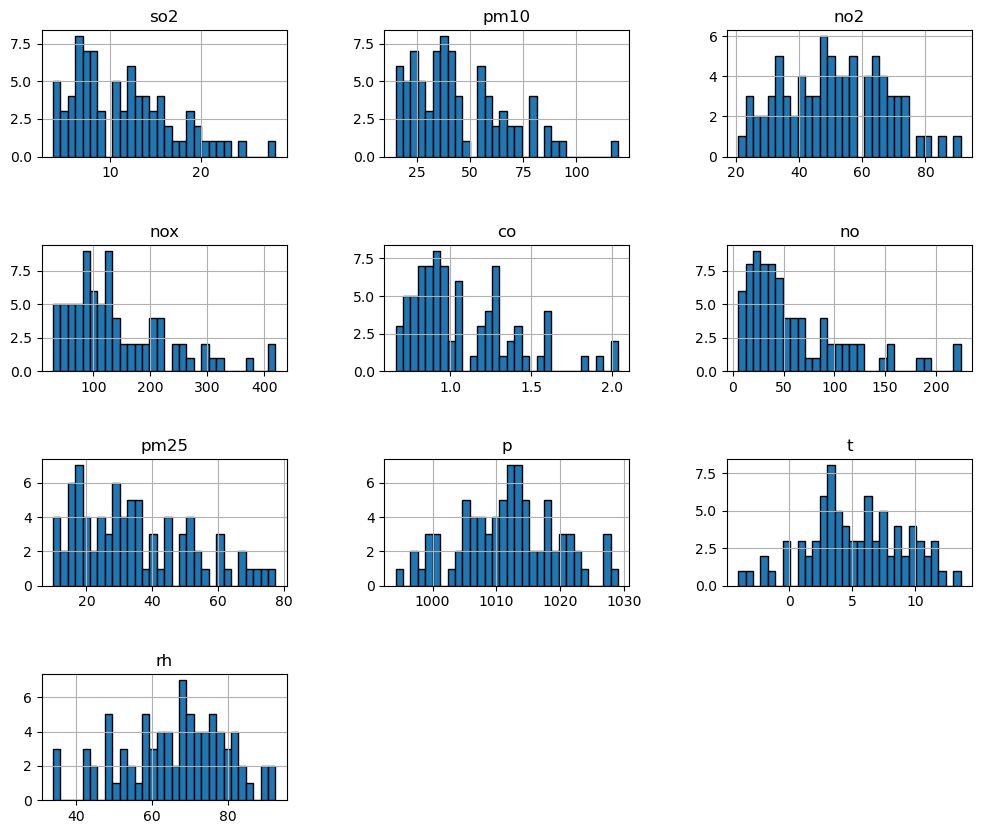

In [7]:

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df.hist(figsize=(12,10),bins=30,edgecolor="black")
plt.subplots_adjust(hspace=0.7,wspace=0.4)

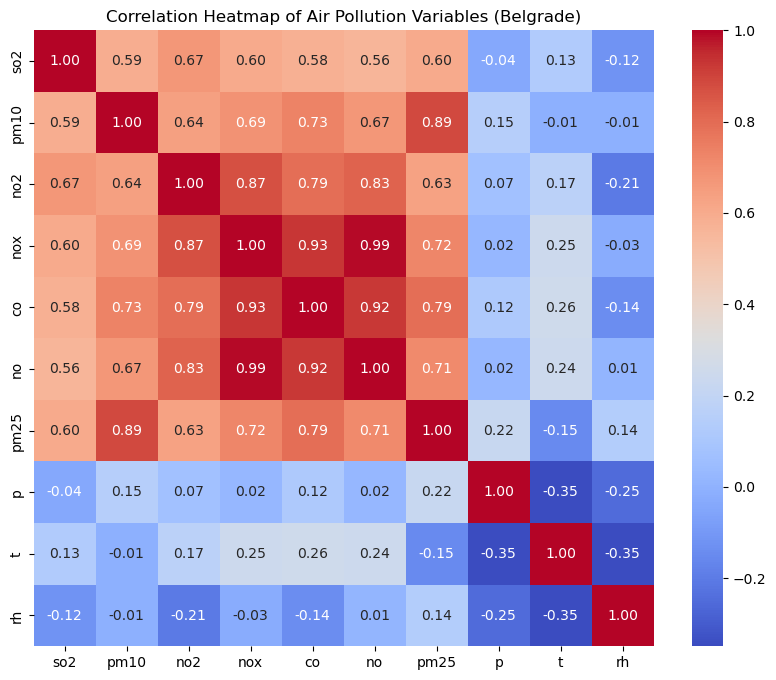

In [8]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Air Pollution Variables (Belgrade)")
plt.show()



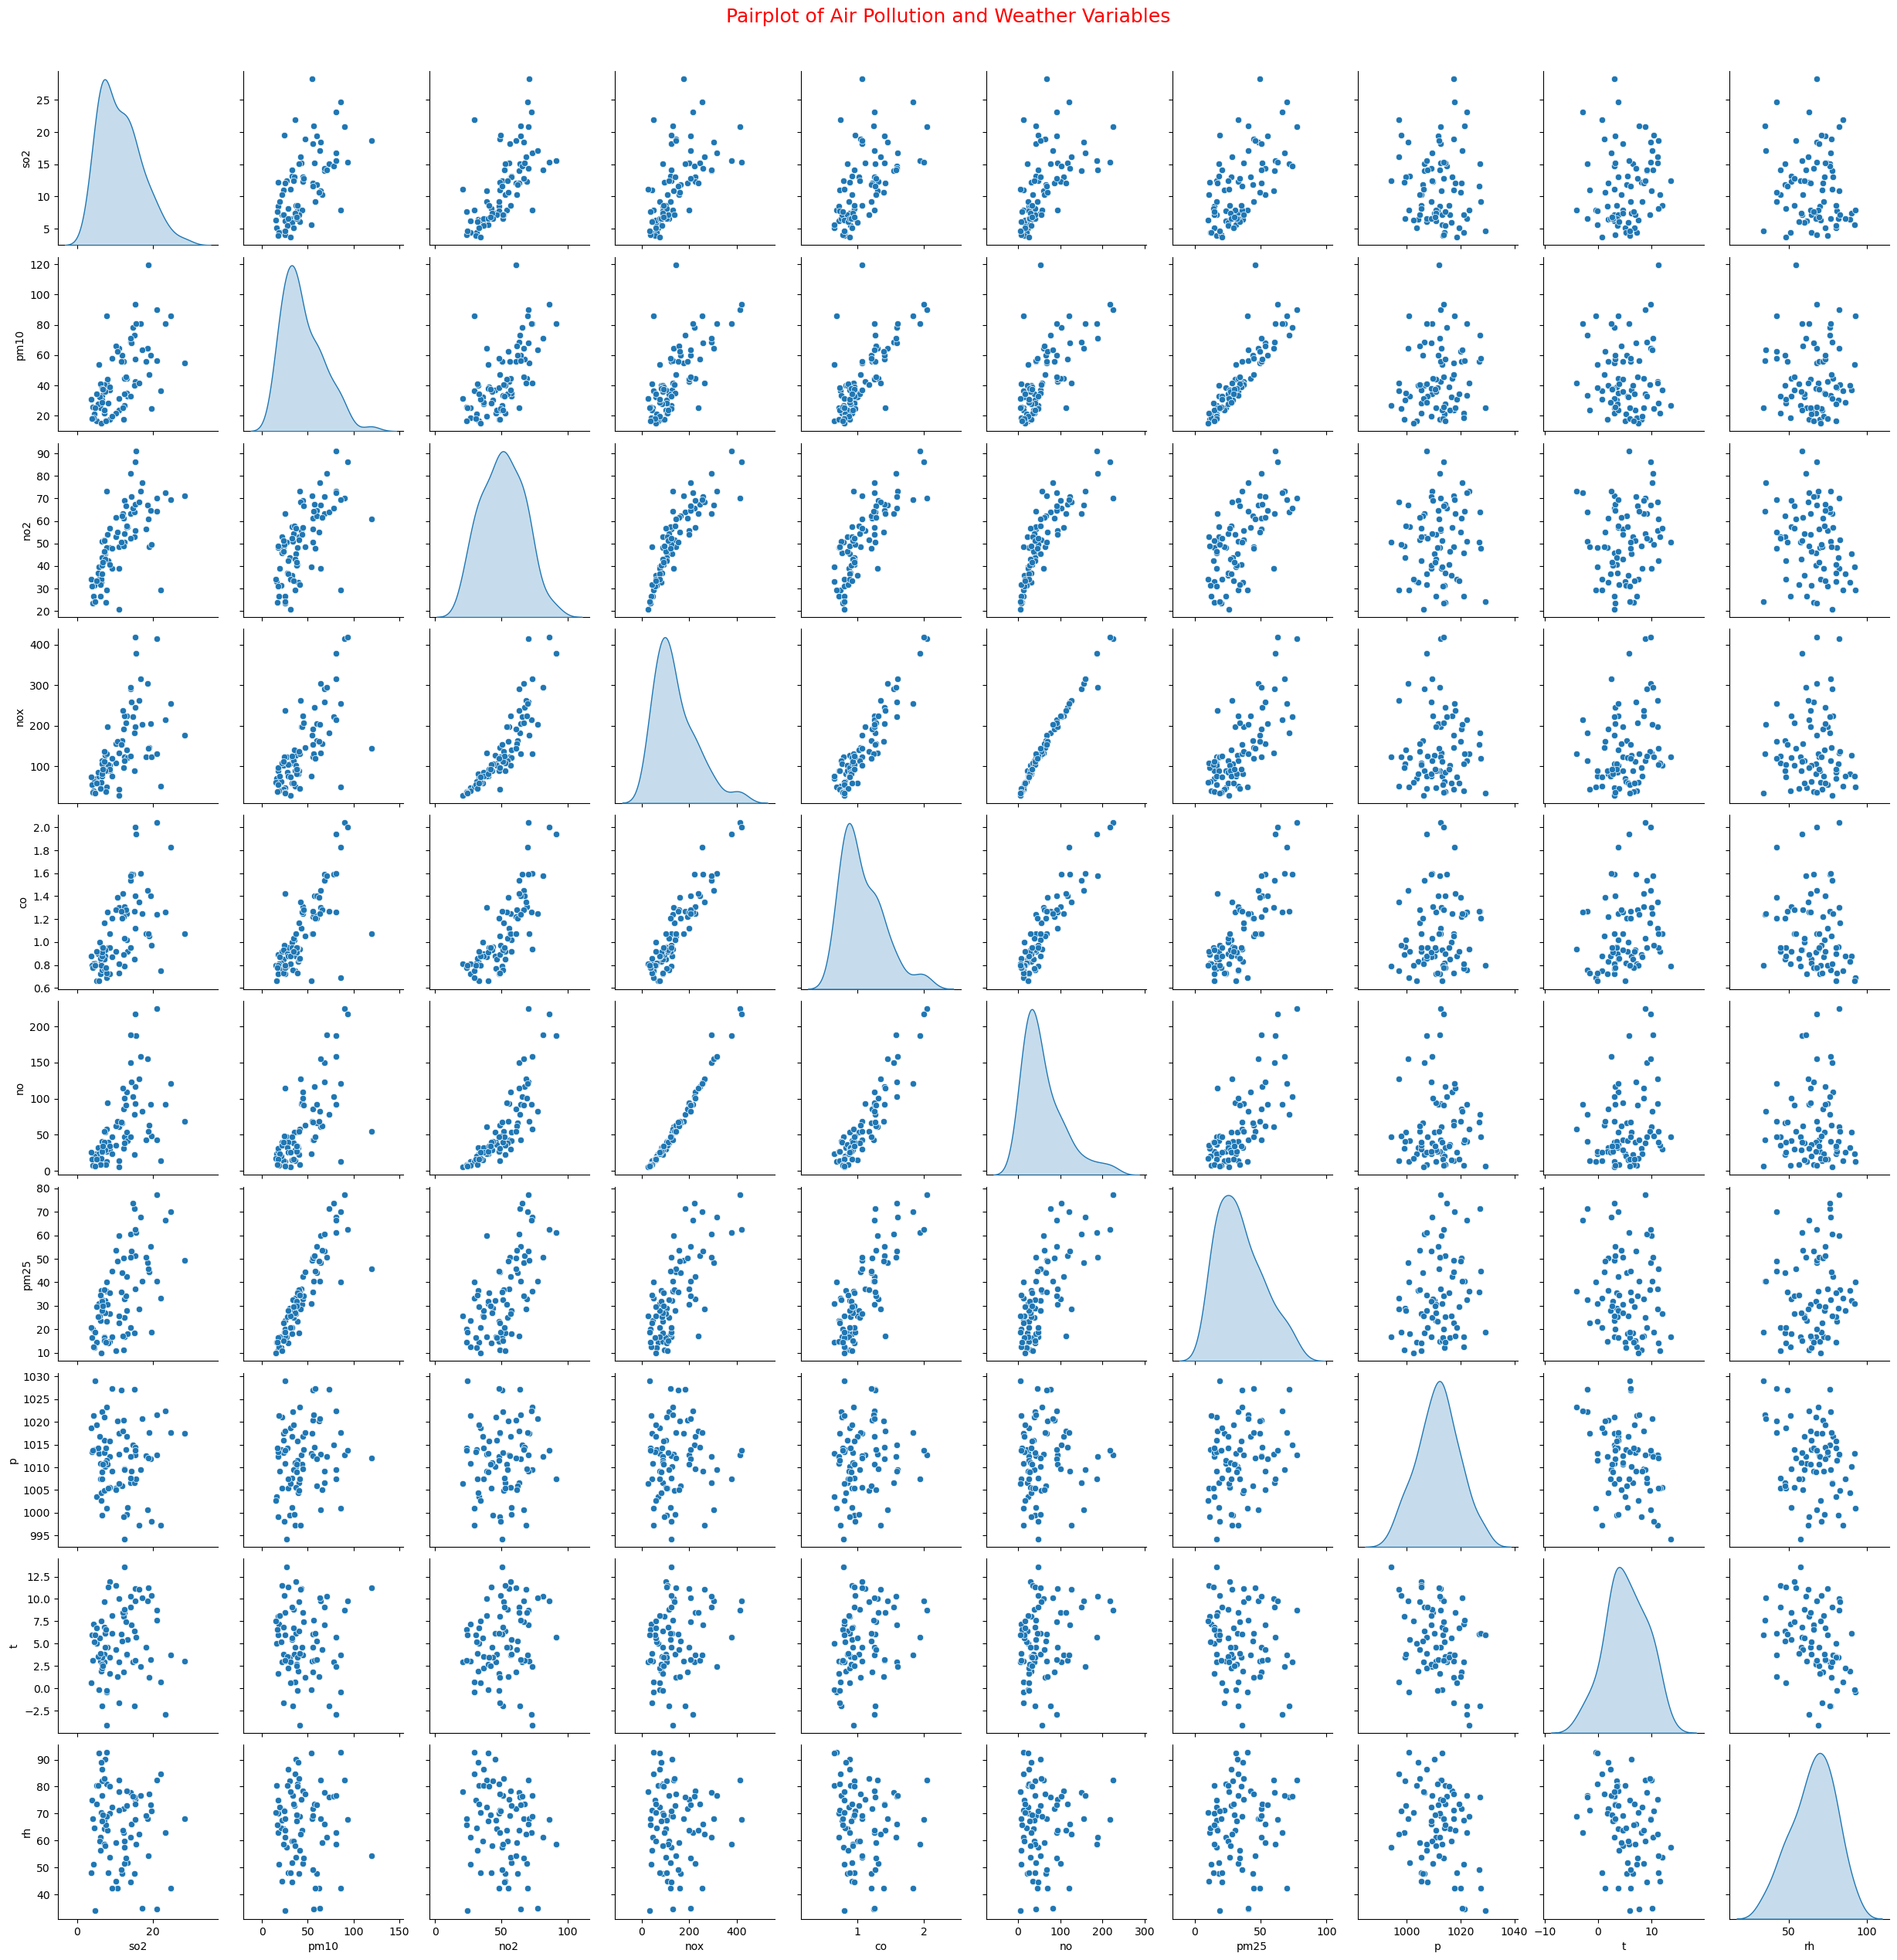

In [9]:
numeric_cols = list(df.select_dtypes(include=['float64', 'int64']).columns)

sns.pairplot(df[numeric_cols], diag_kind="kde")
plt.suptitle("Pairplot of Air Pollution and Weather Variables", 
             fontsize=18, color="red", y=1.02)
plt.show()


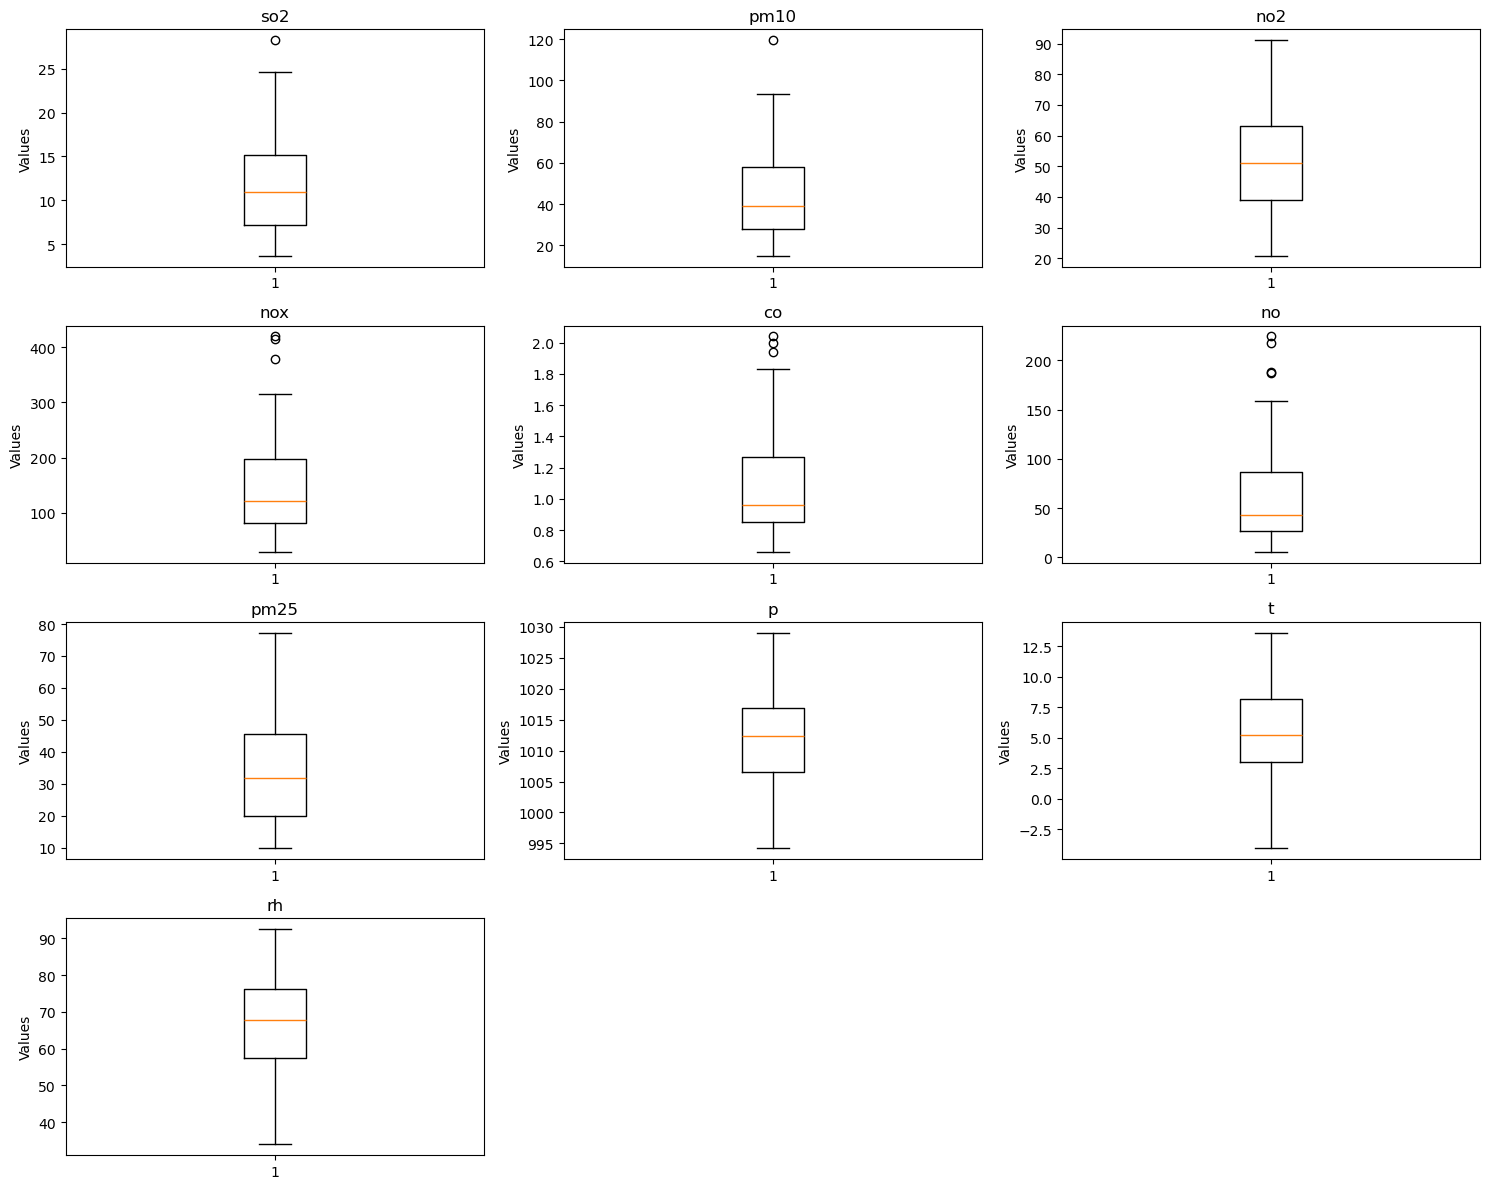

In [10]:

fig, axes = plt.subplots(4, 3, figsize=(15, 12))  # 4 rows, 3 cols
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Values')

# Remove empty subplot if necessary
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [11]:
from sklearn.preprocessing import StandardScaler
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_columns] = scaler.fit_transform(df[numeric_columns])

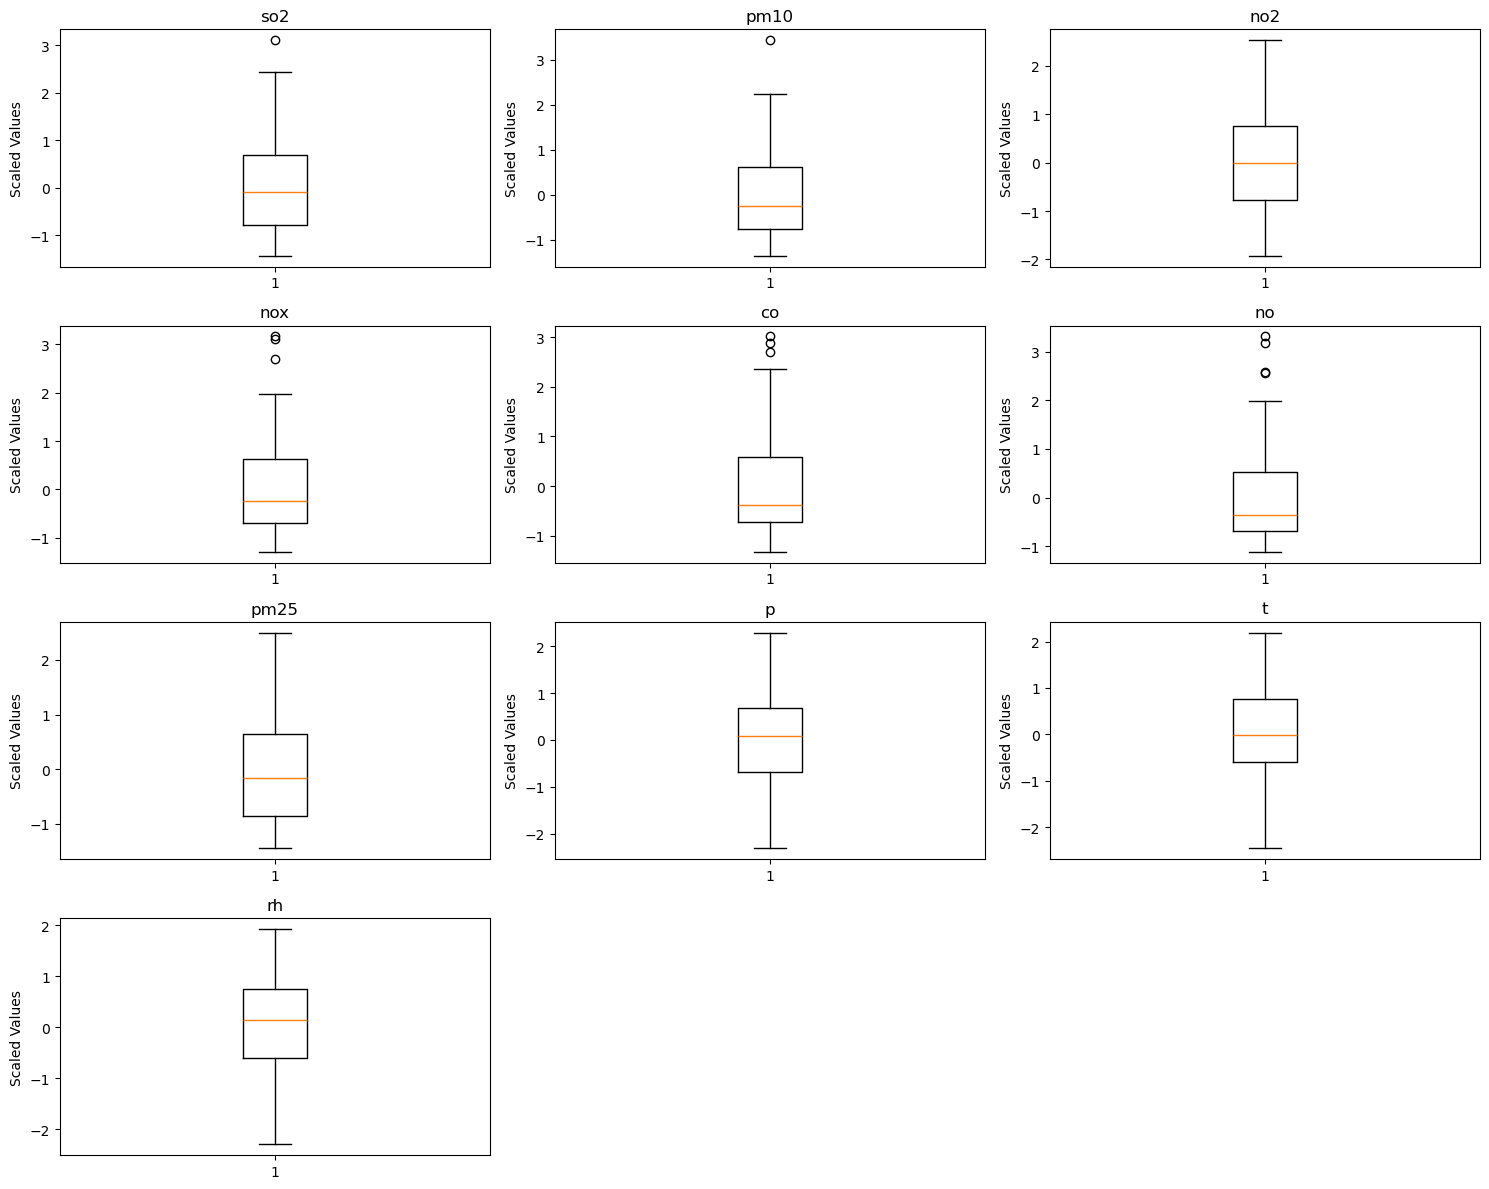

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))  # 4 rows, 3 columns
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_scaled[col].dropna()) 
    axes[i].set_title(col)
    axes[i].set_ylabel('Scaled Values') 

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()